In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

##### 1. Veri setini pandas DataFrame olarak hazırlayın veya CSV dosyasından okuyun.

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

##### 2. Veri setinin ilk satırlarını, satır-sütun sayısını ve hedef değişken dağılımını inceleyin.

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [6]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis= 1, inplace= True)

##### 3. Eksik değer kontrolü yapın. Eksik değer varsa uygun şekilde doldurun veya temizleyin.

In [7]:
df.isna().sum().sum()

np.int64(0)

##### 4. Kategorik değişkenleri One-Hot Encoding veya uygun bir yöntemle sayısal forma dönüştürün.

In [8]:
categoric_cols = ["Geography", "Gender"]

In [9]:
df = pd.get_dummies(data= df, columns= categoric_cols, drop_first= True)

##### 5. Sayısal değişkenlerde gerekli gördüğünüz yerlerde ölçekleme uygulayın.

In [10]:
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

In [11]:
scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

##### 6. En az 1 tane basit öznitelik üretin. Örnek: gelir_grubu, destek_talebi_var_mi, abonelik_yili veya benzer anlamlı bir değişken.

In [12]:
df["TenureAgeRatio"] = df["Tenure"] / df["Age"]

##### 7. Veriyi train, validation ve test kümelerine ayırın. Sınıflandırma problemi olduğu için mümkünse stratify kullanın.

In [13]:
X = df.drop("Exited", axis= 1)
y = df["Exited"]

In [14]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size= 0.15, random_state= 42, stratify= y)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size= 0.2, random_state= 42, stratify= y_train_val)

In [16]:
X_train.shape, X_test.shape, X_val.shape

((6800, 12), (1500, 12), (1700, 12))

##### 8. En az 2 model eğitin. Önerilen modeller: Logistic Regression ve KNN. 

In [17]:
logistic_reg = LogisticRegression(random_state= 42).fit(X_train, y_train)

In [18]:
knn = KNeighborsClassifier().fit(X_train, y_train)

##### 9. Validation sonuçlarına göre modelleri karşılaştırın ve seçtiğiniz modeli test verisi üzerinde değerlendirin.

In [19]:
y_pred_lr = logistic_reg.predict(X_val)

In [20]:
f1_score(y_val, y_pred_lr)

0.3374485596707819

In [21]:
y_pred_knn = knn.predict(X_val)

In [22]:
f1_score(y_val, y_pred_knn)

0.540447504302926

In [23]:
y_pred = knn.predict(X_test)

In [24]:
f1_score(y_test, y_pred)

0.5108910891089109

##### 10. Test seti için confusion matrix, accuracy, precision, recall ve F1-score değerlerini yazdırın.

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1194
           1       0.65      0.42      0.51       306

    accuracy                           0.84      1500
   macro avg       0.76      0.68      0.71      1500
weighted avg       0.82      0.84      0.82      1500



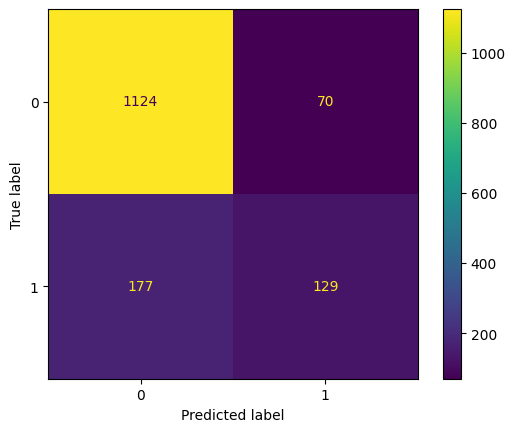

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

##### 11. Kodun sonunda kısa bir yorum çıktısı üretin: Hangi model daha iyi oldu? Sizce neden?

##### Validation sonuçlarına göre KNN modeli, Logistic Regression modeline göre daha yüksek F1 Score elde ettiği için KNN daha başarılı bulunmuştur. Ayrıca KNN test verisinde de validation sonucuna yakın bir score elde etmiştir. Bunun nedeni, KNN modelinin verideki doğrusal olmayan ve benzer gözlemler arasındaki ilişkileri daha iyi yakalayabilmesi olabilir.